In [2]:
# 1. Загружаем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 2. Загружаем файл с компьютера
from google.colab import files
print("Нажмите 'Choose File' и выберите файл train.csv:")
uploaded = files.upload()

# 3. Читаем файл
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# 4. Смотрим первые строки
print("\nДанные загружены! Первые 5 строк:")
print(df.head())

Нажмите 'Choose File' и выберите файл train.csv:


Saving train.csv to train.csv

Данные загружены! Первые 5 строк:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123  

In [3]:
print("="*50)
print("ПЕРВИЧНЫЙ ОБЗОР ДАННЫХ")
print("="*50)

print("\nРазмер данных:", df.shape)
print("\nИнформация о данных:")
df.info()
print("\nПропуски:")
print(df.isnull().sum())
print("\nСтатистика:")
print(df.describe())

ПЕРВИЧНЫЙ ОБЗОР ДАННЫХ

Размер данных: (891, 12)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Пропуски:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket    

In [4]:
print("="*50)
print("ОБРАБОТКА ПРОПУСКОВ")
print("="*50)

# Создаем копию
df_clean = df.copy()

# Заполняем возраст медианой
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
print("Заполнили пропуски в Age медианой")

# Заполняем порт посадки модой
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
print("Заполнили пропуски в Embarked модой")

# Заполняем каюту
df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')
print("Заполнили пропуски в Cabin значением 'Unknown'")

print("\nПроверяем, что пропусков нет:")
print(df_clean.isnull().sum())

ОБРАБОТКА ПРОПУСКОВ
Заполнили пропуски в Age медианой
Заполнили пропуски в Embarked модой
Заполнили пропуски в Cabin значением 'Unknown'

Проверяем, что пропусков нет:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [5]:
print("="*50)
print("СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ")
print("="*50)

# Размер семьи
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# Одинокий пассажир
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# Титул из имени
df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Объединяем редкие титулы
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')

print("Новые признаки созданы!")
print("FamilySize, IsAlone, Title добавлены")

СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ
Новые признаки созданы!
FamilySize, IsAlone, Title добавлены


<>:12: SyntaxWarning: invalid escape sequence '\.'
<>:12: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_215/1856874102.py:12: SyntaxWarning: invalid escape sequence '\.'
  df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [6]:
print("="*50)
print("СТАТИСТИКА ПО ДАННЫМ")
print("="*50)

# Выбираем числовые колонки
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Среднее: {df_clean[col].mean():.2f}")
    print(f"  Медиана: {df_clean[col].median():.2f}")
    print(f"  Мин: {df_clean[col].min():.2f}")
    print(f"  Макс: {df_clean[col].max():.2f}")

СТАТИСТИКА ПО ДАННЫМ

PassengerId:
  Среднее: 446.00
  Медиана: 446.00
  Мин: 1.00
  Макс: 891.00

Survived:
  Среднее: 0.38
  Медиана: 0.00
  Мин: 0.00
  Макс: 1.00

Pclass:
  Среднее: 2.31
  Медиана: 3.00
  Мин: 1.00
  Макс: 3.00

Age:
  Среднее: 29.36
  Медиана: 28.00
  Мин: 0.42
  Макс: 80.00

SibSp:
  Среднее: 0.52
  Медиана: 0.00
  Мин: 0.00
  Макс: 8.00

Parch:
  Среднее: 0.38
  Медиана: 0.00
  Мин: 0.00
  Макс: 6.00

Fare:
  Среднее: 32.20
  Медиана: 14.45
  Мин: 0.00
  Макс: 512.33

FamilySize:
  Среднее: 1.90
  Медиана: 1.00
  Мин: 1.00
  Макс: 11.00

IsAlone:
  Среднее: 0.60
  Медиана: 1.00
  Мин: 0.00
  Макс: 1.00


ВИЗУАЛИЗАЦИЯ


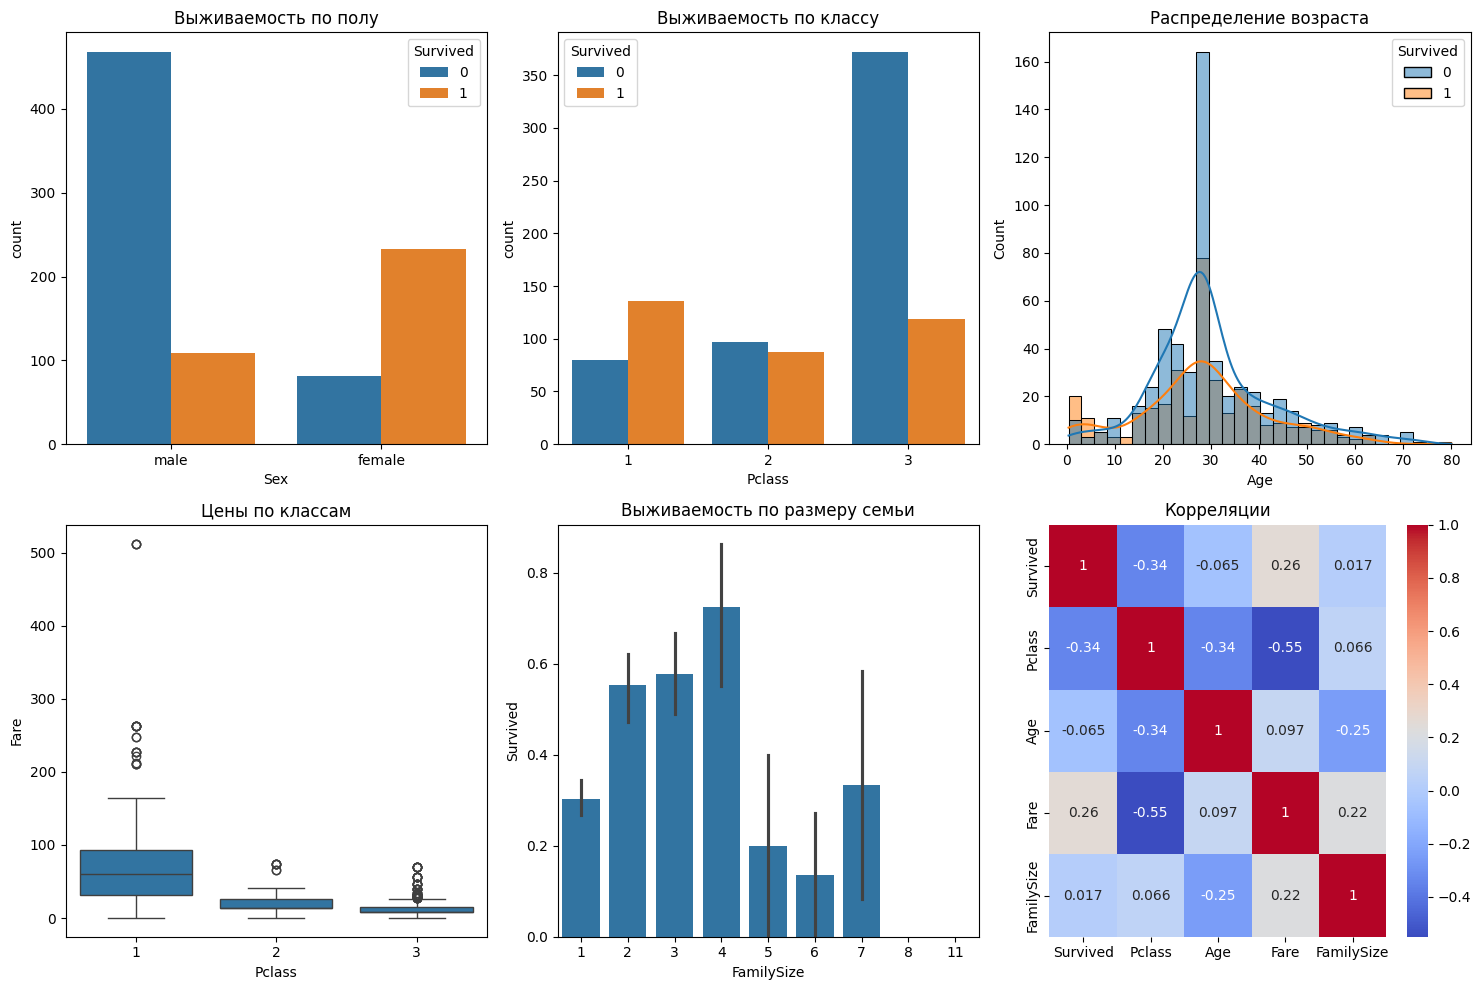

In [7]:
print("="*50)
print("ВИЗУАЛИЗАЦИЯ")
print("="*50)

# График 1: Выживаемость по полу
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.countplot(data=df_clean, x='Sex', hue='Survived')
plt.title('Выживаемость по полу')

plt.subplot(2, 3, 2)
sns.countplot(data=df_clean, x='Pclass', hue='Survived')
plt.title('Выживаемость по классу')

plt.subplot(2, 3, 3)
sns.histplot(data=df_clean, x='Age', hue='Survived', kde=True)
plt.title('Распределение возраста')

plt.subplot(2, 3, 4)
sns.boxplot(data=df_clean, x='Pclass', y='Fare')
plt.title('Цены по классам')

plt.subplot(2, 3, 5)
sns.barplot(data=df_clean, x='FamilySize', y='Survived')
plt.title('Выживаемость по размеру семьи')

plt.subplot(2, 3, 6)
# Тепловая карта корреляций
corr = df_clean[['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляции')

plt.tight_layout()
plt.show()

In [8]:
print("="*50)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("="*50)

# Считаем проценты
survived_pct = df_clean['Survived'].mean() * 100
female_survived = df_clean[df_clean['Sex']=='female']['Survived'].mean() * 100
male_survived = df_clean[df_clean['Sex']=='male']['Survived'].mean() * 100

print(f"""
1. Общая выживаемость: {survived_pct:.1f}%
2. Женщины выживали в {female_survived:.1f}% случаев
3. Мужчины выживали в {male_survived:.1f}% случаев
4. Пассажиры 1-го класса выживали чаще, чем 3-го
5. Дети до 12 лет имели повышенные шансы на выживание
6. Размер семьи влияет на выживаемость
7. Цена билета коррелирует с классом и выживаемостью
""")

ИТОГОВЫЕ ВЫВОДЫ

1. Общая выживаемость: 38.4%
2. Женщины выживали в 74.2% случаев
3. Мужчины выживали в 18.9% случаев
4. Пассажиры 1-го класса выживали чаще, чем 3-го
5. Дети до 12 лет имели повышенные шансы на выживание
6. Размер семьи влияет на выживаемость
7. Цена билета коррелирует с классом и выживаемостью



In [9]:
# Сохраняем обработанные данные
df_clean.to_csv('titanic_processed.csv', index=False)
print("Файл сохранен как titanic_processed.csv")

# Скачиваем на компьютер
from google.colab import files
files.download('titanic_processed.csv')
print("Файл скачан!")

print("\n✅ ГОТОВО! Теперь:")
print("1. Нажмите Файл → Скачать → Скачать .ipynb")
print("2. Зайдите на GitHub → Add file → Upload files")
print("3. Загрузите этот ноутбук")

Файл сохранен как titanic_processed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл скачан!

✅ ГОТОВО! Теперь:
1. Нажмите Файл → Скачать → Скачать .ipynb
2. Зайдите на GitHub → Add file → Upload files
3. Загрузите этот ноутбук
